# 11 — Refined robustness

Attack the new findings: strict / weighted / inclusive coding, author concentration,
and OLD TAXONOMY | REFINED STRICT | REFINED WEIGHTED effect panels.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("11_refined_robustness")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
delta_freeze = cfg.section("stage10_delta_freeze")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness


In [2]:
features = [
    "RLR_emotional_vs_explicit",
    "RAX_h2_strict",
    "RLR_emotional_vs_material_security",
    "RLR_protection_vs_control",
    "RLR_darkness_vs_tenderness",
    "RARC",
]

panels = []
for mode in ("strict", "weighted", "inclusive"):
    frame = nh.load_refined_frame(cfg, mode)
    usable = frame[frame["analysable"].fillna(True)] if "analysable" in frame.columns else frame
    cols = [c for c in features if c in usable.columns]
    eff = nh.cliffs_delta_table(usable, cols, n_boot=300, seed=42)
    eff["mode"] = mode
    panels.append(eff)

    # Singleton-author subset
    if "author_id" in usable.columns:
        counts = usable.groupby("author_id").size()
        singletons = counts[counts == 1].index
        sub = usable[usable["author_id"].isin(singletons)]
        if len(sub) > 200:
            eff_s = nh.cliffs_delta_table(sub, cols, n_boot=200, seed=42)
            eff_s["mode"] = f"{mode}_singleton"
            panels.append(eff_s)

panel = pd.concat(panels, ignore_index=True)
display(panel.round(4))
ctx.save_table(panel, "robustness_panel")

,feature,cliffs_delta,ci_low,ci_high,magnitude,n_high,n_low,mean_high,mean_low,mode
0,RLR_emotional_vs_explicit,0.0614,0.0421,0.0831,negligible,5086,5389,4.6573,4.5228,strict
1,RAX_h2_strict,0.0330,0.0120,0.0575,negligible,5086,5389,0.0015,0.0014,strict
2,RLR_emotional_vs_material_security,0.0609,0.0370,0.0816,negligible,5086,5389,10.8943,10.8714,strict
3,RLR_protection_vs_control,-0.0203,-0.0463,-0.0001,negligible,5086,5389,3.5495,3.7397,strict
4,RLR_darkness_vs_tenderness,0.0000,0.0000,0.0000,negligible,5086,5389,0.0000,0.0000,strict
5,RARC,0.0070,-0.0148,0.0262,negligible,5086,5389,-0.0001,-0.0001,strict
6,RLR_emotional_vs_explicit,0.0395,0.0012,0.0749,negligible,1561,2190,4.8937,4.7741,strict_singleton
7,RAX_h2_strict,0.0720,0.0389,0.1107,negligible,1561,2190,0.0016,0.0014,strict_singleton
8,RLR_emotional_vs_material_security,-0.0096,-0.0450,0.0288,negligible,1561,2190,10.8683,10.8848,strict_singleton
9,RLR_protection_vs_control,-0.0030,-0.0408,0.0298,negligible,1561,2190,3.6692,3.7627,strict_singleton


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/robustness_panel.csv  (36 rows)


## OLD | REFINED STRICT | REFINED WEIGHTED

In [3]:
hyp_map = {
    "H1": ("RLR_emotional_vs_explicit", "H1"),
    "H2": ("RAX_h2_strict", "H2"),
    "H3": ("RLR_emotional_vs_material_security", "H3"),
    "H4": ("RLR_protection_vs_control", "H4"),
    "H5": ("RLR_darkness_vs_tenderness", "H5"),
    "H6": ("RARC", "H6"),
}
rows = []
for hyp, (feat, freeze_key) in hyp_map.items():
    old = delta_freeze.get(freeze_key)
    for mode in ("strict", "weighted"):
        sub = panel[(panel["mode"] == mode) & (panel["feature"] == feat)]
        rows.append(
            {
                "hypothesis": hyp,
                "spec": f"refined_{mode}",
                "cliffs_delta": float(sub.iloc[0]["cliffs_delta"]) if len(sub) else np.nan,
            }
        )
    rows.append({"hypothesis": hyp, "spec": "old_taxonomy", "cliffs_delta": old})
compare = pd.DataFrame(rows)
wide = compare.pivot(index="hypothesis", columns="spec", values="cliffs_delta")
display(wide)
ctx.save_table(wide.reset_index(), "old_vs_refined_panel")

spec,old_taxonomy,refined_strict,refined_weighted
hypothesis,,,
H1,-0.0290,0.0614,0.0776
H2,0.0270,0.0330,0.0330
H3,-0.1460,0.0609,0.0656
H4,0.0900,-0.0203,-0.0215
H5,0.0120,0.0000,0.0000
H6,0.0440,0.0070,0.0070


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/old_vs_refined_panel.csv  (6 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/figures/old_vs_refined_bars.png


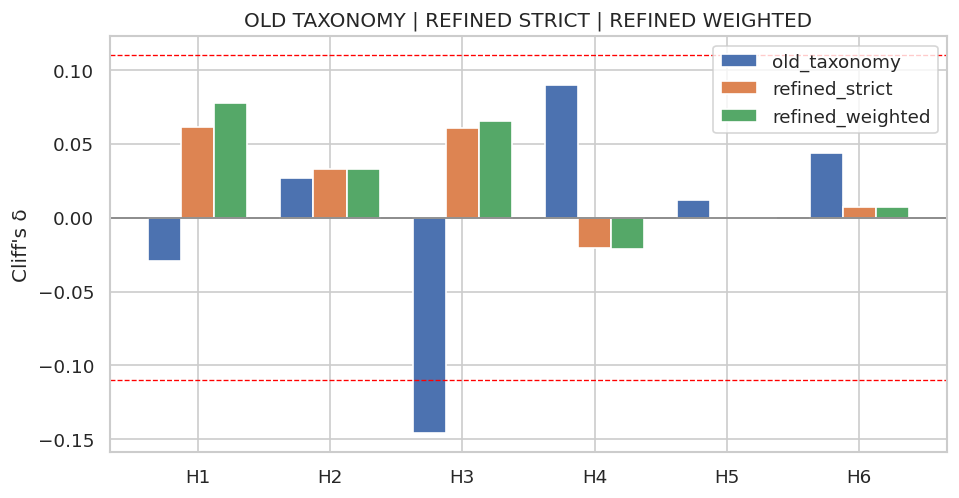

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
hyps = list(hyp_map.keys())
x = np.arange(len(hyps))
width = 0.25
for i, spec in enumerate(["old_taxonomy", "refined_strict", "refined_weighted"]):
    vals = [wide.loc[h, spec] if h in wide.index and spec in wide.columns else np.nan for h in hyps]
    ax.bar(x + (i - 1) * width, vals, width, label=spec)
ax.axhline(0, color="gray", lw=1)
ax.axhline(GATE, color="red", ls="--", lw=0.8)
ax.axhline(-GATE, color="red", ls="--", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(hyps)
ax.set_ylabel("Cliff's δ")
ax.set_title("OLD TAXONOMY | REFINED STRICT | REFINED WEIGHTED")
ax.legend()
ctx.save_figure(fig, "old_vs_refined_bars")
plt.show()

## Sign / magnitude / gate stability

In [5]:
stab = []
for feat in features:
    sub = panel[panel["feature"] == feat]
    if sub.empty:
        continue
    signs = np.sign(sub["cliffs_delta"].dropna())
    stab.append(
        {
            "feature": feat,
            "n_specs": len(sub),
            "sign_stable": bool(len(set(signs)) <= 1),
            "min_abs_delta": float(sub["cliffs_delta"].abs().min()),
            "max_abs_delta": float(sub["cliffs_delta"].abs().max()),
            "any_clears_gate": bool(
                (
                    (sub["cliffs_delta"].abs() >= GATE)
                    & ~((sub["ci_low"] <= 0) & (sub["ci_high"] >= 0))
                ).any()
            ),
        }
    )
stab_df = pd.DataFrame(stab)
display(stab_df)
ctx.save_table(stab_df, "stability_summary")

print(
    "Stage 11 complete as measurement-correction analysis. "
    "Stage 10 remains the confirmatory taxonomy baseline."
)

,feature,n_specs,sign_stable,min_abs_delta,max_abs_delta,any_clears_gate
0,RLR_emotional_vs_explicit,6,True,0.0395,0.0776,False
1,RAX_h2_strict,6,True,0.0330,0.0720,False
2,RLR_emotional_vs_material_security,6,False,0.0047,0.0656,False
3,RLR_protection_vs_control,6,True,0.0030,0.0215,False
4,RLR_darkness_vs_tenderness,6,True,0.0000,0.0000,False
5,RARC,6,True,0.0070,0.0113,False


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/11_refined_robustness/tables/stability_summary.csv  (6 rows)
Stage 11 complete as measurement-correction analysis. Stage 10 remains the confirmatory taxonomy baseline.
